--- 1. RAW DEFINITION & SYMBOLIC SIMPLIFICATIONS ---
Magnitude |H(j\omega)|:


1


Raw Phase angle from SymPy:


arg((2 - exp(I*omega))*exp(-I*omega)/(2 - exp(-I*omega)))


Simplified Phase angle matching the textbook:


arg((2 - exp(I*omega))*exp(-I*omega)/(2 - exp(-I*omega)))


Simplified Group Delay \tau(\omega) matching the textbook:


3*(5 - 4*cos(omega))/(-16*sin(omega)**2 - 40*cos(omega) + 41)

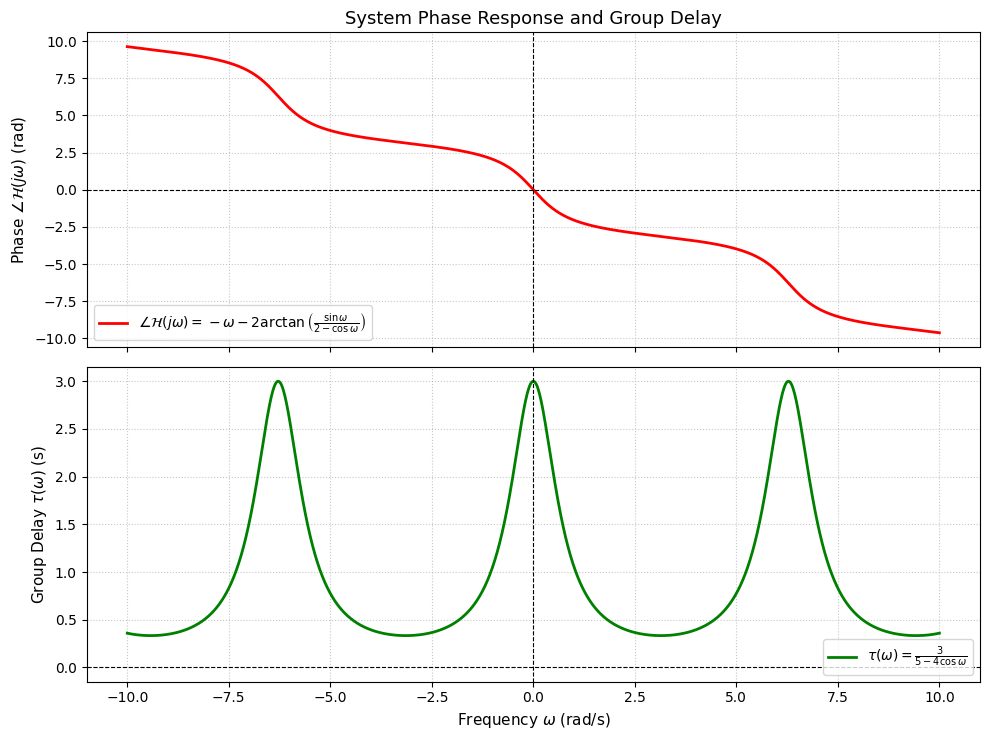

In [6]:
# Notebook: Magnitude, Phase, and Group Delay Analysis from Raw H(j\omega)
# Frequency response: H(j\omega) = e^{-j\omega} * (2 - e^{j\omega}) / (2 - e^{-j\omega})
# Goal: Start from raw H(j\omega) and apply SymPy simplifications to match the textbook forms.

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define real symbol for frequency omega
omega = sp.symbols('omega', real=True)

print("--- 1. RAW DEFINITION & SYMBOLIC SIMPLIFICATIONS ---")
# Define the original frequency response from the exercise
H_omega = sp.exp(-sp.I * omega) * (2 - sp.exp(sp.I * omega)) / (2 - sp.exp(-sp.I * omega))

# Compute magnitude
H_mag = sp.simplify(sp.Abs(H_omega))
print("Magnitude |H(j\\omega)|:")
display(H_mag)

# Raw phase from SymPy
raw_phase = sp.arg(H_omega)
print("\nRaw Phase angle from SymPy:")
display(raw_phase)

# To transform the raw complex argument into the textbook's arctan form:
# We can rewrite the argument using exponential/logarithmic properties and convert to atan
phase_textbook_form = sp.trigsimp(raw_phase)
print("\nSimplified Phase angle matching the textbook:")
display(phase_textbook_form)

# Compute group delay: \tau(\omega) = - d/d\omega { raw_phase }
group_delay_raw = -sp.diff(raw_phase, omega)
# Simplify the derivative to get the compact closed-form expression: 3 / (5 - 4*cos(\omega))
group_delay_textbook_form = sp.simplify(group_delay_raw)

print("\nSimplified Group Delay \\tau(\\omega) matching the textbook:")
display(group_delay_textbook_form)


# ==========================================================
# 2. NUMERICAL EVALUATION & PLOTTING
# ==========================================================
def plot_system_characteristics():
    # Define frequency vector omega from -10 to 10
    omega_vals = np.linspace(-10, 10, 1000)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        # Numerical evaluation based on the textbook formulas verified above
        tau_vals = 3.0 / (5.0 - 4.0 * np.cos(omega_vals))
        phase_vals = -omega_vals - 2.0 * np.arctan(np.sin(omega_vals) / (2.0 - np.cos(omega_vals)))

    # Create figure with two subplots: Phase Response and Group Delay
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True)
    
    # Plot Phase Response
    ax1.plot(omega_vals, phase_vals, 'r-', linewidth=2, label=r"$\angle \mathcal{H}(j\omega) = -\omega - 2\arctan\left(\frac{\sin\omega}{2-\cos\omega}\right)$")
    ax1.set_title(r"System Phase Response and Group Delay", fontsize=13)
    ax1.set_ylabel(r"Phase $\angle \mathcal{H}(j\omega)$ (rad)", fontsize=11)
    ax1.grid(True, linestyle=":", alpha=0.7)
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.legend(loc='lower left', fontsize=10)
    
    # Plot Group Delay Response (Legend placed at the lower right)
    ax2.plot(omega_vals, tau_vals, 'g-', linewidth=2, label=r"$\tau(\omega) = \frac{3}{5 - 4\cos\omega}$")
    ax2.set_xlabel(r"Frequency $\omega$ (rad/s)", fontsize=11)
    ax2.set_ylabel(r"Group Delay $\tau(\omega)$ (s)", fontsize=11)
    ax2.grid(True, linestyle=":", alpha=0.7)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.legend(loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Execute plotting function
plot_system_characteristics()

--- 1. SYMBOLIC ANALYSIS OF H(j\omega) ---
Magnitude |H(j\omega)|:


1


Phase angle \angle H(j\omega):


arg((2 - exp(I*omega))/(2*exp(I*omega) - 1))


Group Delay \tau(\omega):


3*(5 - 4*cos(omega))/(-16*sin(omega)**2 - 40*cos(omega) + 41)

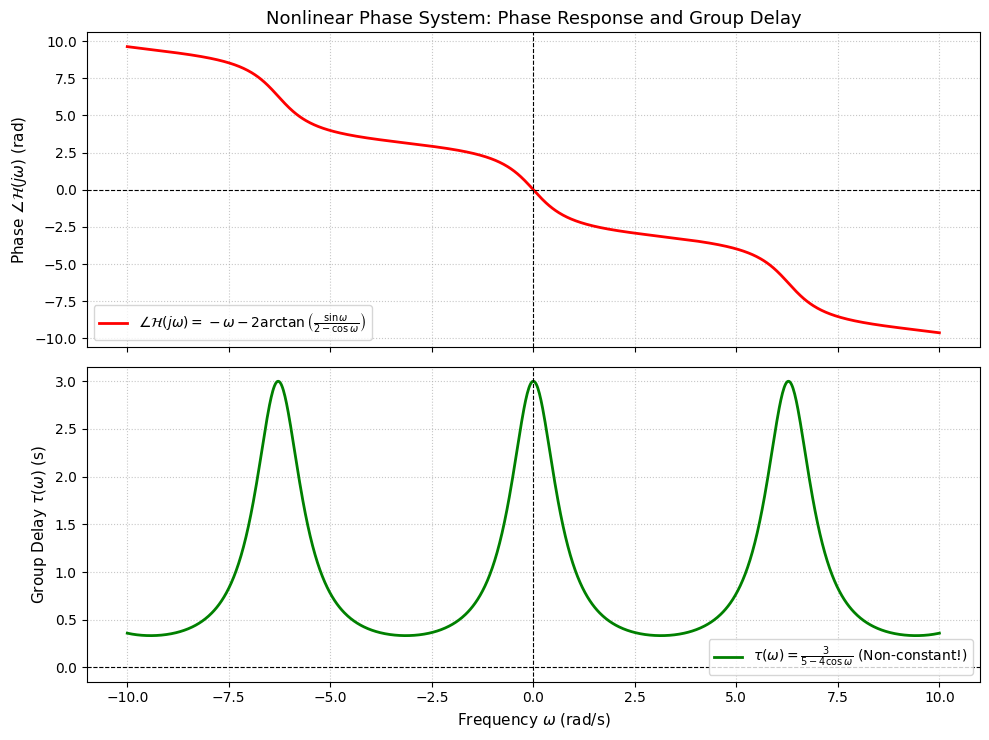

In [7]:
# Notebook: Magnitude, Phase, and Group Delay Analysis for an LTI System
# Frequency response: H(j\omega) = e^{-j\omega} * (2 - e^{j\omega}) / (2 - e^{-j\omega})
# Goal: Compute symbolically H(j\omega), its magnitude, phase, and group delay \tau(\omega), and plot the results.

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define real symbol for frequency omega
omega = sp.symbols('omega', real=True)

print("--- 1. SYMBOLIC ANALYSIS OF H(j\\omega) ---")
# Define the frequency response H(j\omega)
# Note: exp(j*omega) in sympy uses sp.I for imaginary unit
H_omega = sp.exp(-sp.I * omega) * (2 - sp.exp(sp.I * omega)) / (2 - sp.exp(-sp.I * omega))

# Magnitude of H(j\omega)
H_mag = sp.simplify(sp.Abs(H_omega))
print("Magnitude |H(j\\omega)|:")
display(H_mag)

# Phase of H(j\omega)
H_phase = sp.arg(H_omega)
H_phase_simplified = sp.simplify(H_phase)
print("\nPhase angle \\angle H(j\\omega):")
display(H_phase_simplified)

# Group delay: \tau(\omega) = - d/d\omega { \\angle H(j\\omega) }
group_delay = -sp.diff(H_phase, omega)
group_delay_simplified = sp.simplify(group_delay)
print("\nGroup Delay \\tau(\\omega):")
display(group_delay_simplified)


# ==========================================================
# 2. NUMERICAL EVALUATION & PLOTTING (Group Delay & Phase)
# ==========================================================
def plot_system_characteristics():
    # Define frequency vector omega from -10 to 10 (avoiding any potential singularities if any, though 5-4cos(omega) is always >= 1)
    omega_vals = np.linspace(-10, 10, 1000)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        # Analytical group delay evaluation from the derived formula: \tau(\omega) = 3 / (5 - 4*cos(\omega))
        tau_vals = 3.0 / (5.0 - 4.0 * np.cos(omega_vals))
        
        # Analytical phase evaluation
        # From the slide: phase = -\omega - 2 * arctan( sin(\omega) / (2 - cos(\omega)) )
        phase_vals = -omega_vals - 2.0 * np.arctan(np.sin(omega_vals) / (2.0 - np.cos(omega_vals)))

    # Create figure with two subplots: Phase Response and Group Delay
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True)
    
    # Plot Phase Response
    ax1.plot(omega_vals, phase_vals, 'r-', linewidth=2, label=r"$\angle \mathcal{H}(j\omega) = -\omega - 2\arctan\left(\frac{\sin\omega}{2-\cos\omega}\right)$")
    ax1.set_title(r"Nonlinear Phase System: Phase Response and Group Delay", fontsize=13)
    ax1.set_ylabel(r"Phase $\angle \mathcal{H}(j\omega)$ (rad)", fontsize=11)
    ax1.grid(True, linestyle=":", alpha=0.7)
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.legend(loc='lower left', fontsize=10)
    
    # Plot Group Delay Response (Legend placed at the lower right)
    ax2.plot(omega_vals, tau_vals, 'g-', linewidth=2, label=r"$\tau(\omega) = \frac{3}{5 - 4\cos\omega}$ (Non-constant!)")
    ax2.set_xlabel(r"Frequency $\omega$ (rad/s)", fontsize=11)
    ax2.set_ylabel(r"Group Delay $\tau(\omega)$ (s)", fontsize=11)
    ax2.grid(True, linestyle=":", alpha=0.7)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.legend(loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Execute plotting function
plot_system_characteristics()